## Step 1 — Setup and Load master_occupations.csv

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from pathlib import Path
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('..') / 'data' / 'processed' / 'master_occupations.csv'
data = pd.read_csv(DATA_PATH, dtype={'OCC_CODE': str})

print(f'Shape: {data.shape}')
print(f'UAIOE present: {"UAIOE" in data.columns}')
print(f'Missing in UAIOE: {data["UAIOE"].isnull().sum()}')
print(f'\nEmployment outcome columns:')
emp_cols = [c for c in data.columns if 'emp_change' in c]
print(emp_cols)

Shape: (655, 130)
UAIOE present: True
Missing in UAIOE: 0

Employment outcome columns:
['emp_change_pct_19_24', 'emp_change_pct_19_22', 'emp_change_pct_22_24']


## Step 2 — Filter to Occupations with Complete Employment Data

In [62]:
# Filter to occupations with complete employment outcome variables
emp_data = data.dropna(subset=[
    'emp_change_pct_19_24',
    'emp_change_pct_19_22',
    'emp_change_pct_22_24'
]).copy()

print(f'Total occupations in master table:            {len(data)}')
print(f'Occupations with complete employment data:    {len(emp_data)}')
print(f'Dropped due to missing employment outcomes:   {len(data) - len(emp_data)}')

# Quick look at employment change distributions
print(f'\nEmployment change summary (2019→2024):')
print(emp_data['emp_change_pct_19_24'].describe().round(2))

print(f'\nEmployment change summary (2019→2022):')
print(emp_data['emp_change_pct_19_22'].describe().round(2))

print(f'\nEmployment change summary (2022→2024):')
print(emp_data['emp_change_pct_22_24'].describe().round(2))

Total occupations in master table:            655
Occupations with complete employment data:    655
Dropped due to missing employment outcomes:   0

Employment change summary (2019→2024):
count    655.00
mean      -1.00
std       24.28
min      -59.76
25%      -15.02
50%       -1.43
75%       10.95
max      156.25
Name: emp_change_pct_19_24, dtype: float64

Employment change summary (2019→2022):
count    655.00
mean      -3.42
std       20.60
min      -58.62
25%      -13.72
50%       -3.80
75%        5.99
max      243.75
Name: emp_change_pct_19_22, dtype: float64

Employment change summary (2022→2024):
count    655.00
mean       2.61
std       15.22
min      -50.00
25%       -5.06
50%        3.04
75%        9.31
max      158.45
Name: emp_change_pct_22_24, dtype: float64


## Step 3 — OLS Regression: Employment Change 2019→2024 ~ UAIOE (Full Period)

In [63]:
# Full period OLS regression
X_full = sm.add_constant(emp_data['UAIOE'])
y_full = emp_data['emp_change_pct_19_24']

model_emp_full = sm.OLS(y_full, X_full).fit()
print(model_emp_full.summary())

                             OLS Regression Results                             
Dep. Variable:     emp_change_pct_19_24   R-squared:                       0.065
Model:                              OLS   Adj. R-squared:                  0.064
Method:                   Least Squares   F-statistic:                     45.55
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):           3.28e-11
Time:                          22:00:35   Log-Likelihood:                -2996.0
No. Observations:                   655   AIC:                             5996.
Df Residuals:                       653   BIC:                             6005.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9951      0.918

In [64]:
# Print key metrics cleanly
print('OLS — Employment Change 2019→2024 ~ UAIOE')
print(f'  Coefficient (UAIOE): {model_emp_full.params["UAIOE"]:.4f}')
print(f'  R²:                  {model_emp_full.rsquared:.4f}')
print(f'  Adjusted R²:         {model_emp_full.rsquared_adj:.4f}')
print(f'  p-value (UAIOE):     {model_emp_full.pvalues["UAIOE"]:.4f}')
print(f'  F-statistic:         {model_emp_full.fvalue:.4f}')
print(f'  N observations:      {int(model_emp_full.nobs)}')
print()
sig = 'significant' if model_emp_full.pvalues["UAIOE"] < 0.05 else 'NOT significant'
direction = 'positive' if model_emp_full.params["UAIOE"] > 0 else 'negative'
print(f'  Result: {sig} at p<0.05, {direction} relationship')

OLS — Employment Change 2019→2024 ~ UAIOE
  Coefficient (UAIOE): 6.1947
  R²:                  0.0652
  Adjusted R²:         0.0638
  p-value (UAIOE):     0.0000
  F-statistic:         45.5522
  N observations:      655

  Result: significant at p<0.05, positive relationship


## Step 4 — OLS Regression: Employment Change Split by Interval

In [65]:
# 2019-2022 (Pre-GenAI) vs 2022-2024 (GenAI Era)

In [66]:
X = sm.add_constant(emp_data['UAIOE'])

# Interval 1: 2019→2022 Pre-GenAI
model_emp_1922 = sm.OLS(emp_data['emp_change_pct_19_22'], X).fit()

# Interval 2: 2022→2024 GenAI Era
model_emp_2224 = sm.OLS(emp_data['emp_change_pct_22_24'], X).fit()

print('=' * 55)
print('INTERVAL COMPARISON — EMPLOYMENT CHANGE')
print('=' * 55)
print(f'{"":<30} {"2019→2022":>12} {"2022→2024":>12}')
print(f'{"Period":<30} {"Pre-GenAI":>12} {"GenAI Era":>12}')
print('-' * 55)
print(f'{"Coefficient (UAIOE)":<30} '
      f'{model_emp_1922.params["UAIOE"]:>12.4f} '
      f'{model_emp_2224.params["UAIOE"]:>12.4f}')
print(f'{"R²":<30} '
      f'{model_emp_1922.rsquared:>12.4f} '
      f'{model_emp_2224.rsquared:>12.4f}')
print(f'{"Adjusted R²":<30} '
      f'{model_emp_1922.rsquared_adj:>12.4f} '
      f'{model_emp_2224.rsquared_adj:>12.4f}')
print(f'{"p-value":<30} '
      f'{model_emp_1922.pvalues["UAIOE"]:>12.4f} '
      f'{model_emp_2224.pvalues["UAIOE"]:>12.4f}')
print(f'{"N observations":<30} '
      f'{int(model_emp_1922.nobs):>12} '
      f'{int(model_emp_2224.nobs):>12}')
print()
stronger = '2022→2024 GenAI Era' if model_emp_2224.rsquared > model_emp_1922.rsquared else '2019→2022 Pre-GenAI'
print(f'Effect stronger in: {stronger}')

INTERVAL COMPARISON — EMPLOYMENT CHANGE
                                  2019→2022    2022→2024
Period                            Pre-GenAI    GenAI Era
-------------------------------------------------------
Coefficient (UAIOE)                  4.0208       1.9453
R²                                   0.0382       0.0164
Adjusted R²                          0.0367       0.0149
p-value                              0.0000       0.0010
N observations                          655          655

Effect stronger in: 2019→2022 Pre-GenAI


In [67]:
# Full summaries for both interval models
print('FULL SUMMARY — 2019→2022 (Pre-GenAI):')
print(model_emp_1922.summary())

print('\nFULL SUMMARY — 2022→2024 (GenAI Era):')
print(model_emp_2224.summary())

FULL SUMMARY — 2019→2022 (Pre-GenAI):
                             OLS Regression Results                             
Dep. Variable:     emp_change_pct_19_22   R-squared:                       0.038
Model:                              OLS   Adj. R-squared:                  0.037
Method:                   Least Squares   F-statistic:                     25.91
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):           4.68e-07
Time:                          22:00:35   Log-Likelihood:                -2897.6
No. Observations:                   655   AIC:                             5799.
Df Residuals:                       653   BIC:                             5808.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Step 5 — Scatter Plots: UAIOE vs Employment Change for All Three Periods

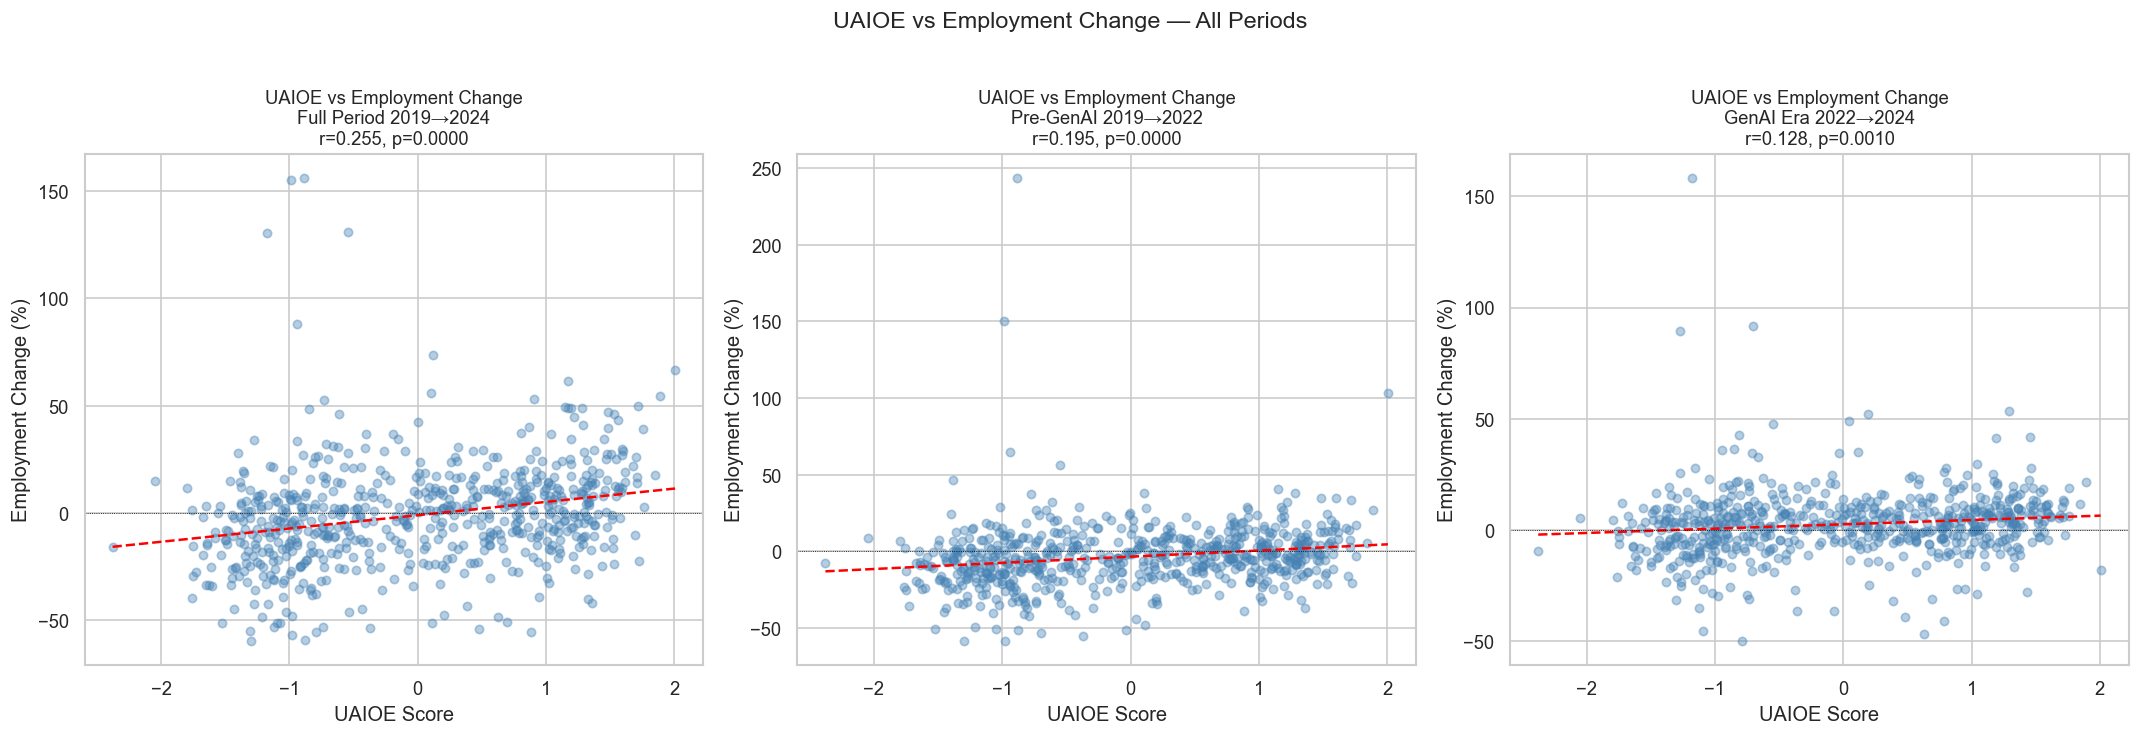

In [68]:
periods = [
    ('emp_change_pct_19_24', 'Full Period 2019→2024'),
    ('emp_change_pct_19_22', 'Pre-GenAI 2019→2022'),
    ('emp_change_pct_22_24', 'GenAI Era 2022→2024')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, periods):
    plot_df = emp_data.dropna(subset=[col])
    ax.scatter(plot_df['UAIOE'], plot_df[col],
               alpha=0.4, s=25, color='steelblue')

    m, b, r, p, _ = stats.linregress(plot_df['UAIOE'], plot_df[col])
    x_line = np.linspace(plot_df['UAIOE'].min(),
                         plot_df['UAIOE'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red',
            linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')

    ax.set_title(f'UAIOE vs Employment Change\n{title}\nr={r:.3f}, p={p:.4f}',
                 fontsize=11)
    ax.set_xlabel('UAIOE Score')
    ax.set_ylabel('Employment Change (%)')

plt.suptitle('UAIOE vs Employment Change — All Periods',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [69]:
# Correlation values for all three periods
print('Pearson correlations — UAIOE vs employment change:')
for col, label in periods:
    df_sub = emp_data.dropna(subset=[col])
    r, p = stats.pearsonr(df_sub['UAIOE'], df_sub[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {label:<30} r={r:.4f}  p={p:.4f}  {sig}')

Pearson correlations — UAIOE vs employment change:
  Full Period 2019→2024          r=0.2554  p=0.0000  ***
  Pre-GenAI 2019→2022            r=0.1954  p=0.0000  ***
  GenAI Era 2022→2024            r=0.1279  p=0.0010  **


## Step 6 — Random Forest Regression: Employment Change 2019→2024

In [70]:
# Define the 93 O*NET feature columns
exclude = [
    'OCC_CODE', 'OCC_TITLE', 'occ_major_group',
    'AIOE', 'AIOE_z', 'UAIOE', 'UAIOE_ev',
    'AIOE_rank', 'UAIOE_rank', 'rank_diff', 'abs_rank_diff',
    'cluster', 'cluster_label',
    'TOT_EMP_2019', 'TOT_EMP_2022', 'TOT_EMP_2024',
    'real_median_wage_2019', 'real_median_wage_2022', 'real_median_wage_2024',
    'emp_change_pct_19_24', 'emp_change_pct_19_22', 'emp_change_pct_22_24',
    'wage_change_pct_19_24', 'wage_change_pct_19_22', 'wage_change_pct_22_24'
]

feature_cols = [
    c for c in data.columns
    if c not in exclude and not c.startswith('A_PCT')
]

print(f'Feature columns: {len(feature_cols)}')

# Prepare RF data
rf_data = emp_data.dropna(subset=['emp_change_pct_19_24'])
X_rf = rf_data[feature_cols]
y_rf = rf_data['emp_change_pct_19_24']

print(f'Samples for RF: {len(rf_data)}')

Feature columns: 93
Samples for RF: 655


In [71]:
from sklearn.metrics import mean_squared_error

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

# Fit Random Forest
rf_emp = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf_emp.fit(X_train, y_train)

# Test set performance
y_pred = rf_emp.predict(X_test)
r2_emp = r2_score(y_test, y_pred)
rmse_emp = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'\nRandom Forest — Employment Change 2019→2024')
print(f'  R² (test set):  {r2_emp:.4f}')
print(f'  RMSE:           {rmse_emp:.4f}')

# 5-fold cross-validation
cv_scores = cross_val_score(
    rf_emp, X_rf, y_rf, cv=5, scoring='r2'
)
print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Training samples: 524
Test samples:     131

Random Forest — Employment Change 2019→2024
  R² (test set):  -0.0821
  RMSE:           20.4162
  CV R² (5-fold): -0.0118 ± 0.0545


In [72]:
# Compare OLS vs RF on same outcome
print('Model comparison — Employment Change 2019→2024:')
print(f'  OLS R²:         {model_emp_full.rsquared:.4f}')
print(f'  RF R² (test):   {r2_emp:.4f}')
print(f'  RF CV R²:       {cv_scores.mean():.4f}')
better = 'Random Forest' if r2_emp > model_emp_full.rsquared else 'OLS'
print(f'  Better model:   {better}')

Model comparison — Employment Change 2019→2024:
  OLS R²:         0.0652
  RF R² (test):   -0.0821
  RF CV R²:       -0.0118
  Better model:   OLS


## Step 7 — Feature Importance: Which O*NET Features Best Predict Employment Change

In [73]:
# Feature importances from Random Forest
importances = pd.Series(
    rf_emp.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print('Top 20 O*NET features predicting employment change 2019→2024:')
print(importances.head(20).round(4).to_string())

print('\nBottom 10 least important features:')
print(importances.tail(10).round(4).to_string())

Top 20 O*NET features predicting employment change 2019→2024:
getting_information                                         0.0851
problem_sensitivity                                         0.0503
developing_and_building_teams                               0.0419
deductive_reasoning                                         0.0388
performing_general_physical_activities                      0.0277
communicating_with_supervisors,_peers,_or_subordinates      0.0255
providing_consultation_and_advice_to_others                 0.0235
coaching_and_developing_others                              0.0216
controlling_machines_and_processes                          0.0211
resolving_conflicts_and_negotiating_with_others             0.0209
oral_expression                                             0.0202
updating_and_using_relevant_knowledge                       0.0197
establishing_and_maintaining_interpersonal_relationships    0.0189
inductive_reasoning                                         0.0179


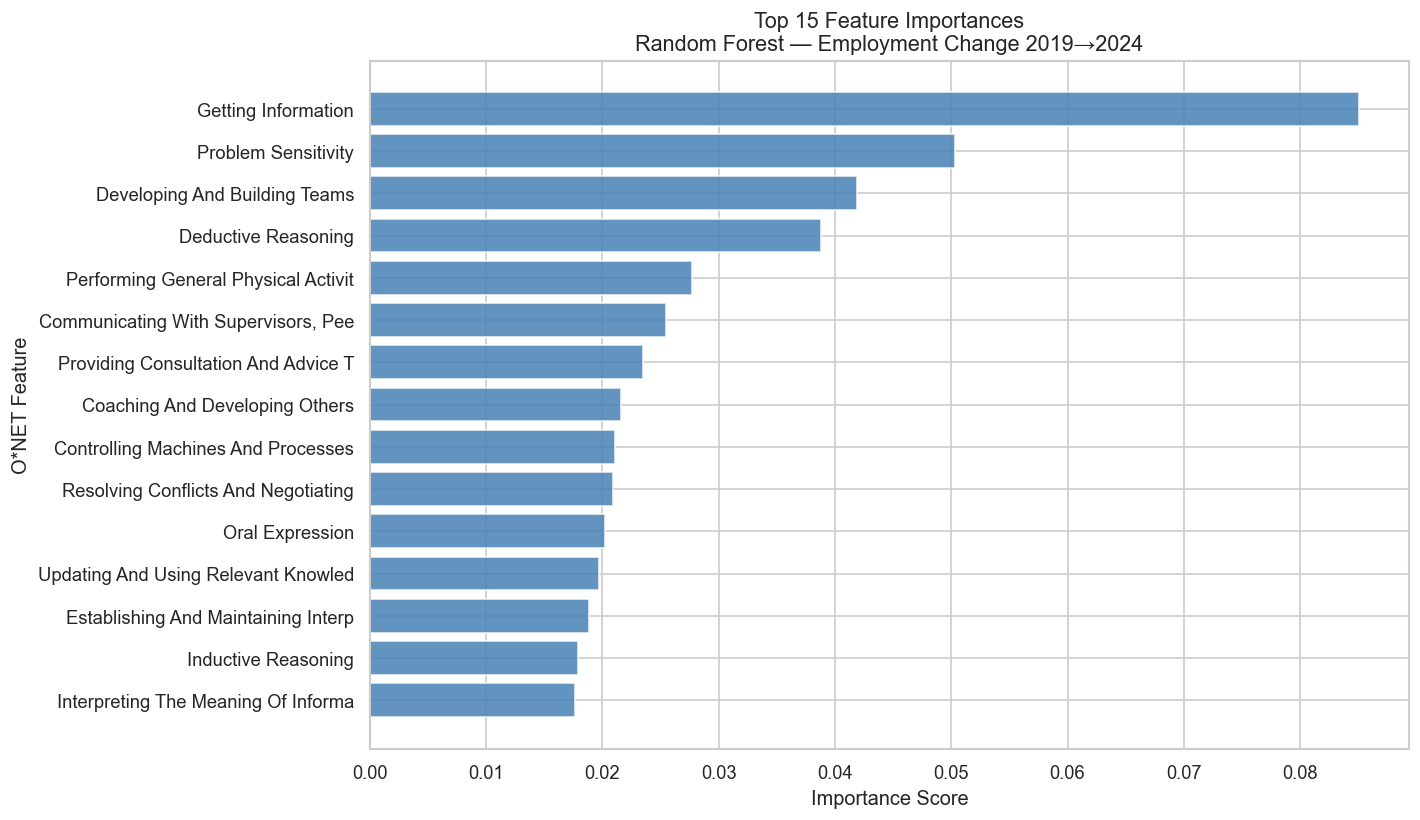

In [74]:
# Feature importance bar chart
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    [c.replace('_', ' ').title()[:35] for c in top15.index[::-1]],
    top15.values[::-1],
    color='steelblue', alpha=0.85, edgecolor='white'
)
ax.set_title('Top 15 Feature Importances\nRandom Forest — Employment Change 2019→2024',
             fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('O*NET Feature')
plt.tight_layout()
plt.show()

In [75]:
# Are AI-relevant features (cognitive abilities) in the top predictors?
cognitive = [
    'oral_comprehension', 'written_comprehension', 'deductive_reasoning',
    'inductive_reasoning', 'information_ordering', 'mathematical_reasoning',
    'oral_expression', 'written_expression', 'fluency_of_ideas'
]

print('Importance of cognitive/AI-relevant features for employment prediction:')
for feat in cognitive:
    if feat in importances.index:
        rank = importances.index.get_loc(feat) + 1
        print(f'  {feat:<35} importance={importances[feat]:.4f}  rank={rank}')

Importance of cognitive/AI-relevant features for employment prediction:
  oral_comprehension                  importance=0.0065  rank=53
  written_comprehension               importance=0.0068  rank=52
  deductive_reasoning                 importance=0.0388  rank=4
  inductive_reasoning                 importance=0.0179  rank=14
  information_ordering                importance=0.0048  rank=64
  mathematical_reasoning              importance=0.0041  rank=70
  oral_expression                     importance=0.0202  rank=11
  written_expression                  importance=0.0024  rank=85
  fluency_of_ideas                    importance=0.0165  rank=18


## Step 8 — Save Employment Results to Dictionary

In [76]:
# Compile all employment results into a dictionary
emp_results = {
    'ols_full_coef':    model_emp_full.params["UAIOE"],
    'ols_full_r2':      model_emp_full.rsquared,
    'ols_full_adj_r2':  model_emp_full.rsquared_adj,
    'ols_full_p':       model_emp_full.pvalues["UAIOE"],
    'ols_full_n':       int(model_emp_full.nobs),
    'ols_1922_coef':    model_emp_1922.params["UAIOE"],
    'ols_1922_r2':      model_emp_1922.rsquared,
    'ols_1922_p':       model_emp_1922.pvalues["UAIOE"],
    'ols_2224_coef':    model_emp_2224.params["UAIOE"],
    'ols_2224_r2':      model_emp_2224.rsquared,
    'ols_2224_p':       model_emp_2224.pvalues["UAIOE"],
    'rf_r2_test':       r2_emp,
    'rf_rmse':          rmse_emp,
    'rf_cv_r2_mean':    cv_scores.mean(),
    'rf_cv_r2_std':     cv_scores.std()
}

print('EMPLOYMENT RESULTS:')
print(json.dumps(
    {k: round(float(v), 4) for k, v in emp_results.items()},
    indent=2
))

# Save feature importances
importances.reset_index().rename(
    columns={'index': 'feature', 0: 'importance'}
).to_csv(
    '../data/processed/rf_emp_feature_importance.csv',
    index=False
)
print('\nSaved: rf_emp_feature_importance.csv')

EMPLOYMENT RESULTS:
{
  "ols_full_coef": 6.1947,
  "ols_full_r2": 0.0652,
  "ols_full_adj_r2": 0.0638,
  "ols_full_p": 0.0,
  "ols_full_n": 655.0,
  "ols_1922_coef": 4.0208,
  "ols_1922_r2": 0.0382,
  "ols_1922_p": 0.0,
  "ols_2224_coef": 1.9453,
  "ols_2224_r2": 0.0164,
  "ols_2224_p": 0.001,
  "rf_r2_test": -0.0821,
  "rf_rmse": 20.4162,
  "rf_cv_r2_mean": -0.0118,
  "rf_cv_r2_std": 0.0545
}

Saved: rf_emp_feature_importance.csv
